# ResNet50

In [ ]:
import os
import json
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

In [ ]:
print(subprocess.getoutput("nvidia-smi"))

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus)

if len(gpus) == 0:
    raise RuntimeError("Chưa có GPU. Vào Runtime -> Change runtime type -> T4 GPU -> Restart runtime rồi chạy lại.")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(e)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("Đang dùng GPU:", tf.test.gpu_device_name())
print("Mixed precision:", mixed_precision.global_policy())

Tue Jun  2 02:29:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             30W /   70W |     639MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!unzip -o "/content/dataset_classification.zip"

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: dataset_classification/train/bad/img772.jpg  
  inflating: dataset_classification/train/bad/img773.jpg  
  inflating: dataset_classification/train/bad/img774.jpg  
  inflating: dataset_classification/train/bad/img775.jpg  
  inflating: dataset_classification/train/bad/img776.jpg  
  inflating: dataset_classification/train/bad/img777.jpg  
  inflating: dataset_classification/train/bad/img778.jpg  
  inflating: dataset_classification/train/bad/img779.jpg  
  inflating: dataset_classification/train/bad/img78.jpg  
  inflating: dataset_classification/train/bad/img780.jpg  
  inflating: dataset_classification/train/bad/img781.jpg  
  inflating: dataset_classification/train/bad/img782.jpg  
  inflating: dataset_classification/train/bad/img783.jpg  
  inflating: dataset_classification/train/bad/img784.jpg  
  inflating: dataset_classification/train/bad/img785.jpg  
  inflating: dataset_classification/train/bad/img786.jpg  


In [ ]:
DATASET_DIR = Path("/content/dataset_classification")

if not DATASET_DIR.exists():
    DATASET_DIR = Path("/content/dataset_classification")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

RESULTS_DIR = Path("/content/training_results/resnet50")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["bad", "good", "shell"]
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 50
EPOCHS_FINE_TUNE = 50
SEED = 42

print("Dataset:", DATASET_DIR)
print("Kết quả:", RESULTS_DIR)

Dataset: /content/dataset_classification
Kết quả: /content/training_results/resnet50


In [ ]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not split_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục: {split_dir}")

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print("\n", split_dir)
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            raise FileNotFoundError(f"Thiếu lớp {cls}: {cls_dir}")
        count = len([p for p in cls_dir.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]])
        print(cls, count)


 /content/dataset_classification/train
bad 1256
good 1356
shell 1604

 /content/dataset_classification/val
bad 464
good 701
shell 623

 /content/dataset_classification/test
bad 322
good 316
shell 675


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_gen.class_indices)

Found 4216 images belonging to 3 classes.
Found 1788 images belonging to 3 classes.
Found 1313 images belonging to 3 classes.
{'bad': 0, 'good': 1, 'shell': 2}


In [ ]:
y_train = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_NAMES)),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

with open(RESULTS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(train_gen.class_indices, f, ensure_ascii=False, indent=4)

with open(RESULTS_DIR / "class_weights.json", "w", encoding="utf-8") as f:
    json.dump(class_weights, f, ensure_ascii=False, indent=4)

print(class_weights)

{0: 1.118895966029724, 1: 1.0363815142576205, 2: 0.8761429758935994}


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
best_model_path = RESULTS_DIR / "resnet50_best_model.keras"
head_log_path = RESULTS_DIR / "resnet50_head_history.csv"

callbacks_head = [
    ModelCheckpoint(str(best_model_path), monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(str(head_log_path))
]

with tf.device("/GPU:0"):
    history_head = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_HEAD,
        class_weight=class_weights,
        callbacks=callbacks_head
    )

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6201 - loss: 0.9369
Epoch 1: val_accuracy improved from None to 0.97931, saving model to /content/training_results/resnet50/resnet50_best_model.keras

Epoch 1: finished saving model to /content/training_results/resnet50/resnet50_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 95s 576ms/step - accuracy: 0.7685 - loss: 0.5886 - val_accuracy: 0.9793 - val_loss: 0.1069 - learning_rate: 1.0000e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9064 - loss: 0.2627
Epoch 2: val_accuracy improved from 0.97931 to 0.98154, saving model to /content/training_results/resnet50/resnet50_best_model.keras

Epoch 2: finished saving model to /content/training_results/resnet50/resnet50_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 56s 422ms/step - accuracy: 0.9165 - loss: 0.2403 - val_accuracy: 0.9815 - val_loss: 0.0759 - learning_rate: 1.0000e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9402 

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_log_path = RESULTS_DIR / "resnet50_finetune_history.csv"
callbacks_fine = [
    ModelCheckpoint(str(best_model_path), monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-8, verbose=1),
    CSVLogger(str(fine_log_path))
]

with tf.device("/GPU:0"):
    history_fine = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_FINE_TUNE,
        class_weight=class_weights,
        callbacks=callbacks_fine
    )

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9822 - loss: 0.0692
Epoch 1: val_accuracy improved from None to 0.98546, saving model to /content/training_results/resnet50/resnet50_best_model.keras

Epoch 1: finished saving model to /content/training_results/resnet50/resnet50_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 100s 589ms/step - accuracy: 0.9820 - loss: 0.0606 - val_accuracy: 0.9855 - val_loss: 0.0448 - learning_rate: 1.0000e-05
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9851 - loss: 0.0524
Epoch 2: val_accuracy improved from 0.98546 to 0.98602, saving model to /content/training_results/resnet50/resnet50_best_model.keras

Epoch 2: finished saving model to /content/training_results/resnet50/resnet50_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 58s 437ms/step - accuracy: 0.9867 - loss: 0.0465 - val_accuracy: 0.9860 - val_loss: 0.0471 - learning_rate: 1.0000e-05
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9837

In [ ]:
def history_to_df(history, phase):
    df = pd.DataFrame(history.history)
    df.insert(0, "epoch", np.arange(1, len(df) + 1))
    df.insert(1, "phase", phase)
    return df

history_df = pd.concat([
    history_to_df(history_head, "head"),
    history_to_df(history_fine, "fine_tune")
], ignore_index=True)

history_df.to_csv(RESULTS_DIR / "resnet50_training_history.csv", index=False, encoding="utf-8-sig")
model.save(RESULTS_DIR / "resnet50_final_model.keras")

history_df.tail()

,epoch,phase,accuracy,loss,val_accuracy,val_loss,learning_rate
95,46,fine_tune,0.999763,0.002683,0.995526,0.017450,8.100000e-08
96,47,fine_tune,0.998577,0.003289,0.995526,0.017365,2.430000e-08
97,48,fine_tune,0.998102,0.003525,0.995526,0.017669,2.430000e-08
98,49,fine_tune,0.999288,0.001522,0.995526,0.017594,2.430000e-08
99,50,fine_tune,0.999763,0.001582,0.995526,0.017549,2.430000e-08


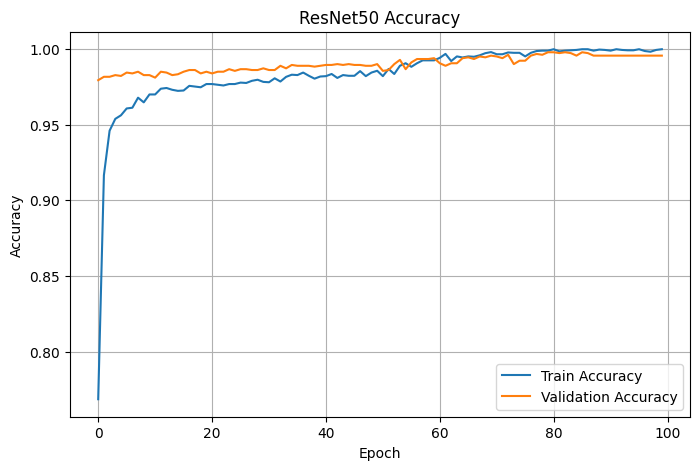

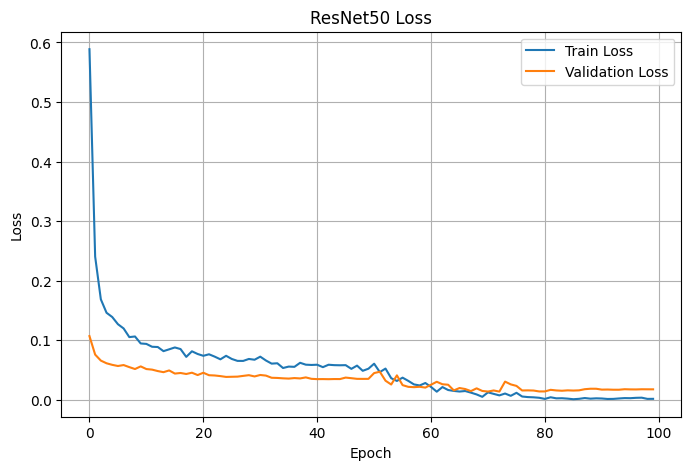

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"].values, label="Train Accuracy")
plt.plot(history_df["val_accuracy"].values, label="Validation Accuracy")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "resnet50_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"].values, label="Train Loss")
plt.plot(history_df["val_loss"].values, label="Validation Loss")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "resnet50_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
best_model = load_model(best_model_path)

test_gen.reset()
pred_probs = best_model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report_text)

with open(RESULTS_DIR / "resnet50_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(RESULTS_DIR / "resnet50_classification_report.csv", encoding="utf-8-sig")

summary_df = pd.DataFrame([{
    "model": "ResNet50",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": report_dict["macro avg"]["precision"],
    "recall_macro": report_dict["macro avg"]["recall"],
    "f1_macro": report_dict["macro avg"]["f1-score"],
    "precision_weighted": report_dict["weighted avg"]["precision"],
    "recall_weighted": report_dict["weighted avg"]["recall"],
    "f1_weighted": report_dict["weighted avg"]["f1-score"]
}])

summary_df.to_csv(RESULTS_DIR / "resnet50_summary_metrics.csv", index=False, encoding="utf-8-sig")
summary_df

42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 277ms/step
              precision    recall  f1-score   support

         bad     0.9758    1.0000    0.9877       322
        good     1.0000    0.9810    0.9904       316
       shell     1.0000    0.9970    0.9985       675

    accuracy                         0.9939      1313
   macro avg     0.9919    0.9927    0.9922      1313
weighted avg     0.9941    0.9939    0.9939      1313



,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,ResNet50,0.993907,0.991919,0.992683,0.992221,0.994055,0.993907,0.993921


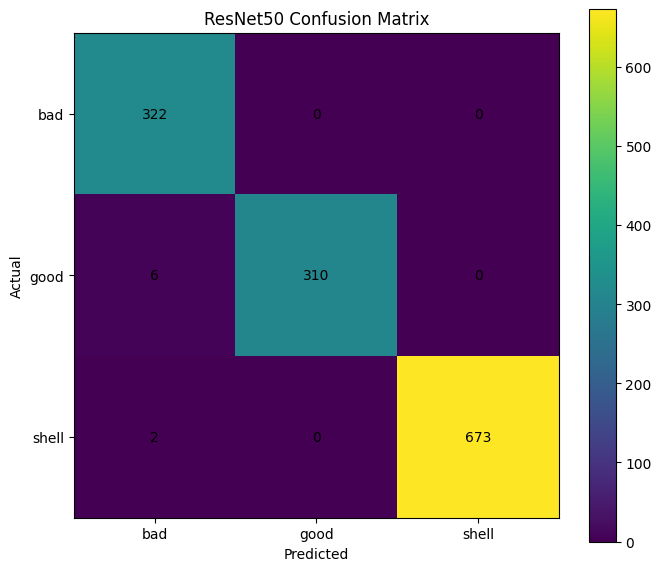

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet50_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    RESULTS_DIR / "resnet50_confusion_matrix.csv",
    encoding="utf-8-sig"
)

In [ ]:
pred_df = pd.DataFrame({
    "filename": test_gen.filenames,
    "actual": [CLASS_NAMES[i] for i in y_true],
    "predicted": [CLASS_NAMES[i] for i in y_pred]
})

for i, cls in enumerate(CLASS_NAMES):
    pred_df[f"prob_{cls}"] = pred_probs[:, i]

pred_df.to_csv(RESULTS_DIR / "resnet50_test_predictions.csv", index=False, encoding="utf-8-sig")
pred_df.head()

,filename,actual,predicted,prob_bad,prob_good,prob_shell
0,bad/img1.jpg,bad,bad,0.992639,1.011157e-05,7.351193e-03
1,bad/img10.jpg,bad,bad,1.000000,5.533027e-12,1.694887e-20
2,bad/img100.jpg,bad,bad,1.000000,2.683361e-11,4.575447e-11
3,bad/img101.jpg,bad,bad,0.999512,1.080629e-05,4.768047e-04
4,bad/img102.jpg,bad,bad,1.000000,1.913084e-14,6.005393e-11


In [ ]:
zip_base = "/content/resnet50_training_results"
zip_file = zip_base + ".zip"

if os.path.exists(zip_file):
    os.remove(zip_file)

shutil.make_archive(zip_base, "zip", RESULTS_DIR)
print("Đã tạo:", zip_file)

from google.colab import files
files.download(zip_file)

Đã tạo: /content/resnet50_training_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/BCKLTN/resnet50_output")
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for item in RESULTS_DIR.iterdir():
    dst = DRIVE_OUTPUT_DIR / item.name
    if item.is_file():
        shutil.copy2(item, dst)

shutil.copy2("/content/resnet50_training_results.zip", "/content/drive/MyDrive/BCKLTN/resnet50_training_results.zip")
print("Đã lưu thêm vào Drive:", DRIVE_OUTPUT_DIR)

Đã lưu thêm vào Drive: /content/drive/MyDrive/BCKLTN/resnet50_output


In [ ]:
import os
import shutil
from google.colab import files

RESULTS_DIR = "/content/training_results"
ZIP_NAME = "/content/training_results"

if not os.path.exists(RESULTS_DIR):
    raise FileNotFoundError(f"Không tìm thấy folder: {RESULTS_DIR}")

shutil.make_archive(ZIP_NAME, "zip", RESULTS_DIR)

files.download(ZIP_NAME + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>